FIRST 5 ROWS
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  

DATASET SHAPE
(3276, 10)

COLUMN NAMES
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes'

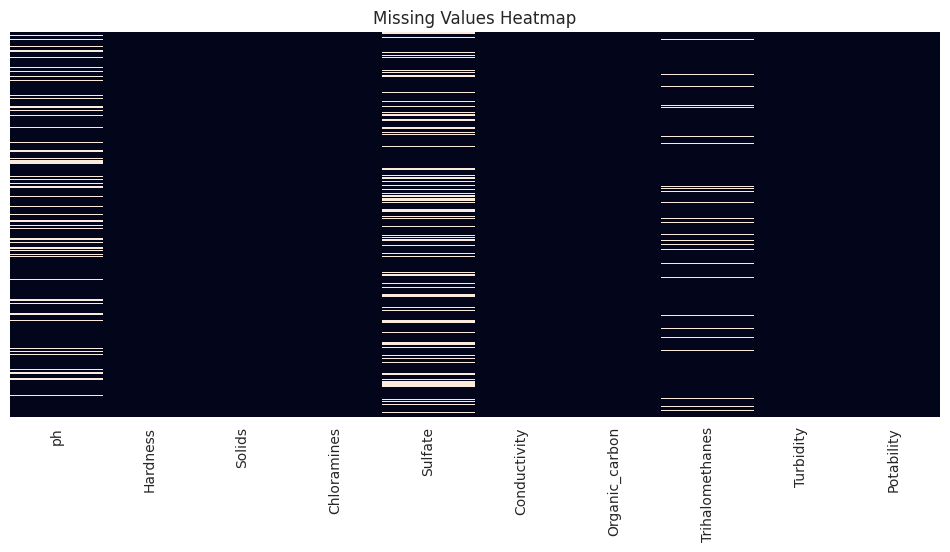


DUPLICATE ROWS
0

POTABILITY DISTRIBUTION
Potability
0    1998
1    1278
Name: count, dtype: int64

POTABILITY PERCENTAGE
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


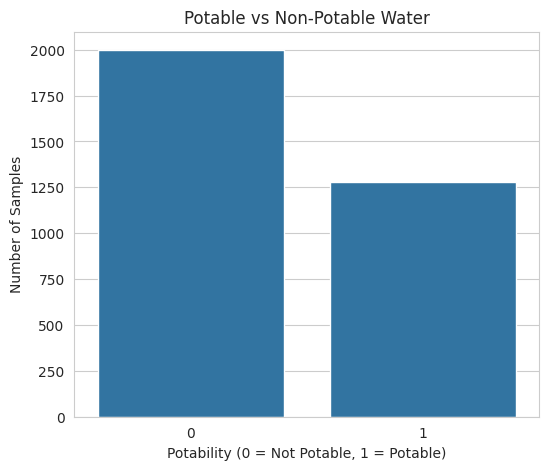

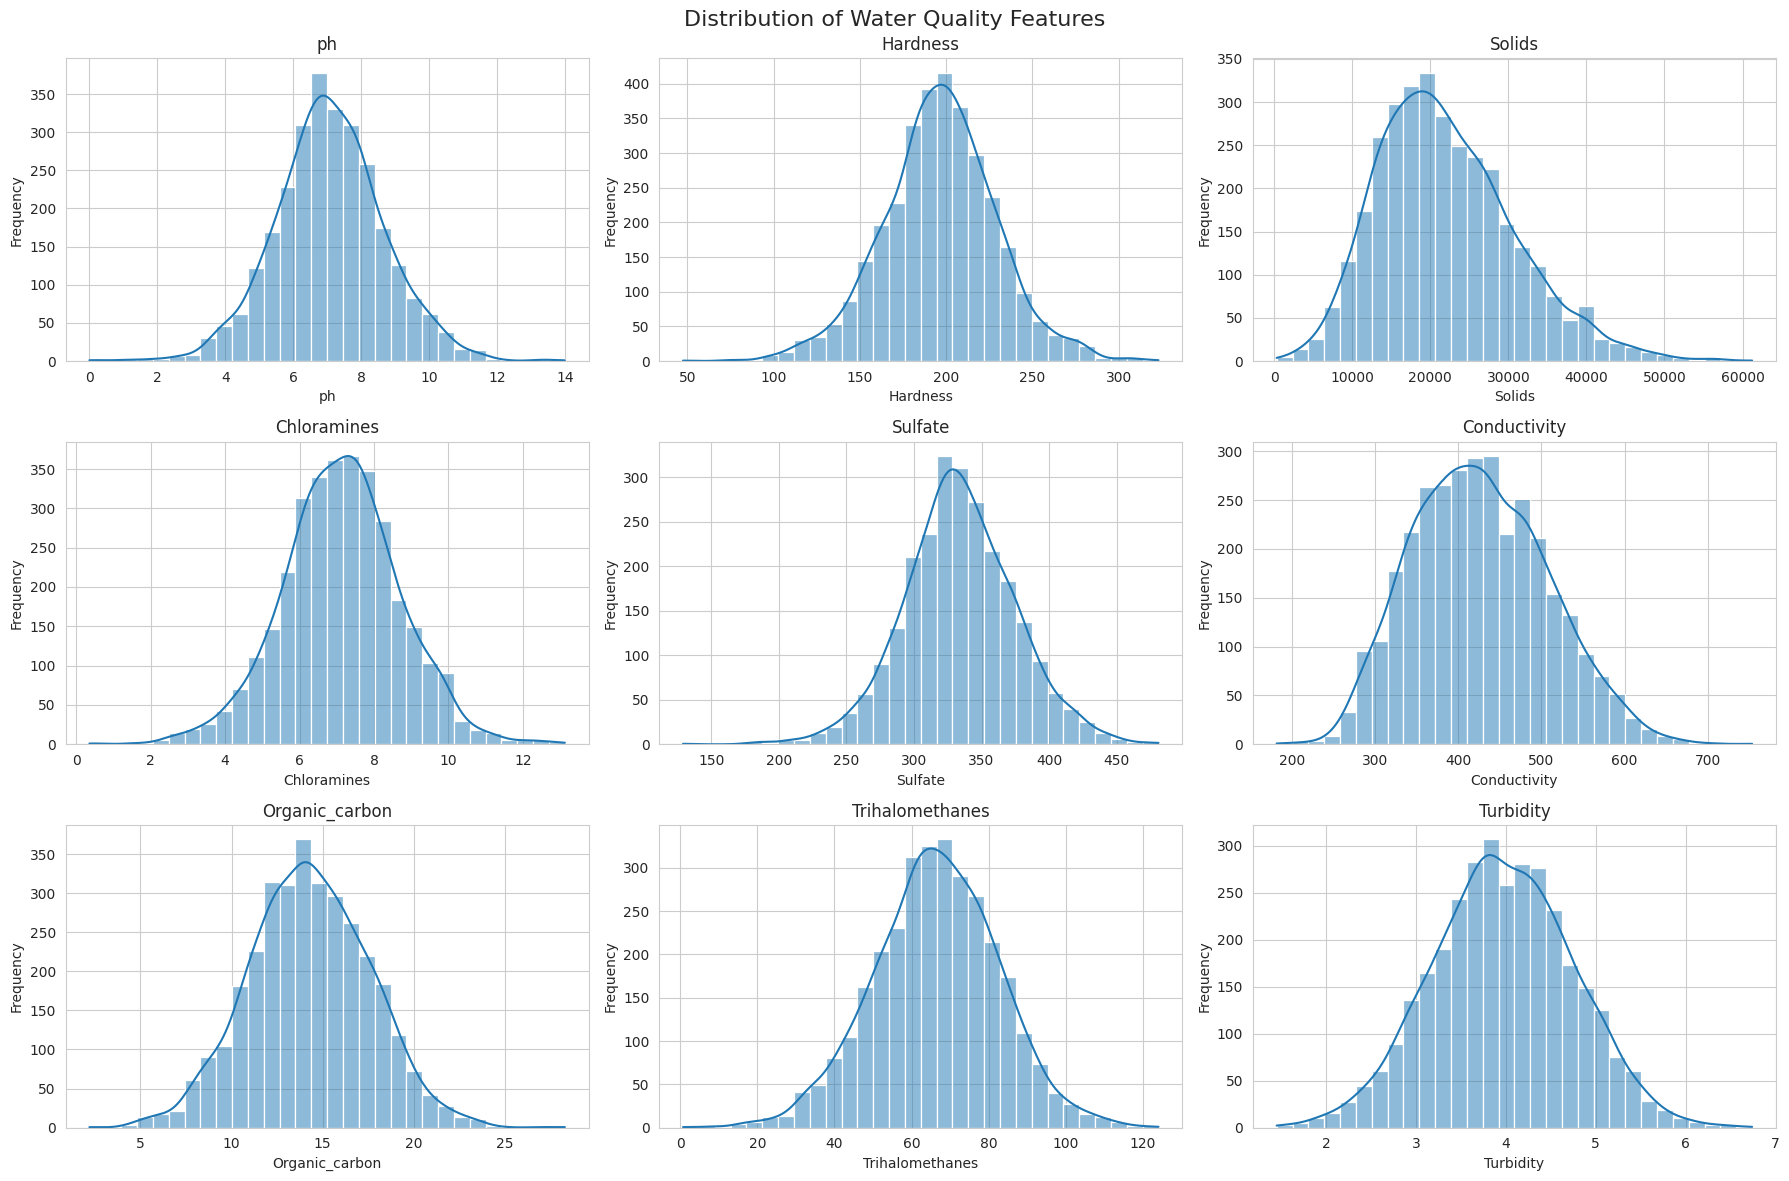

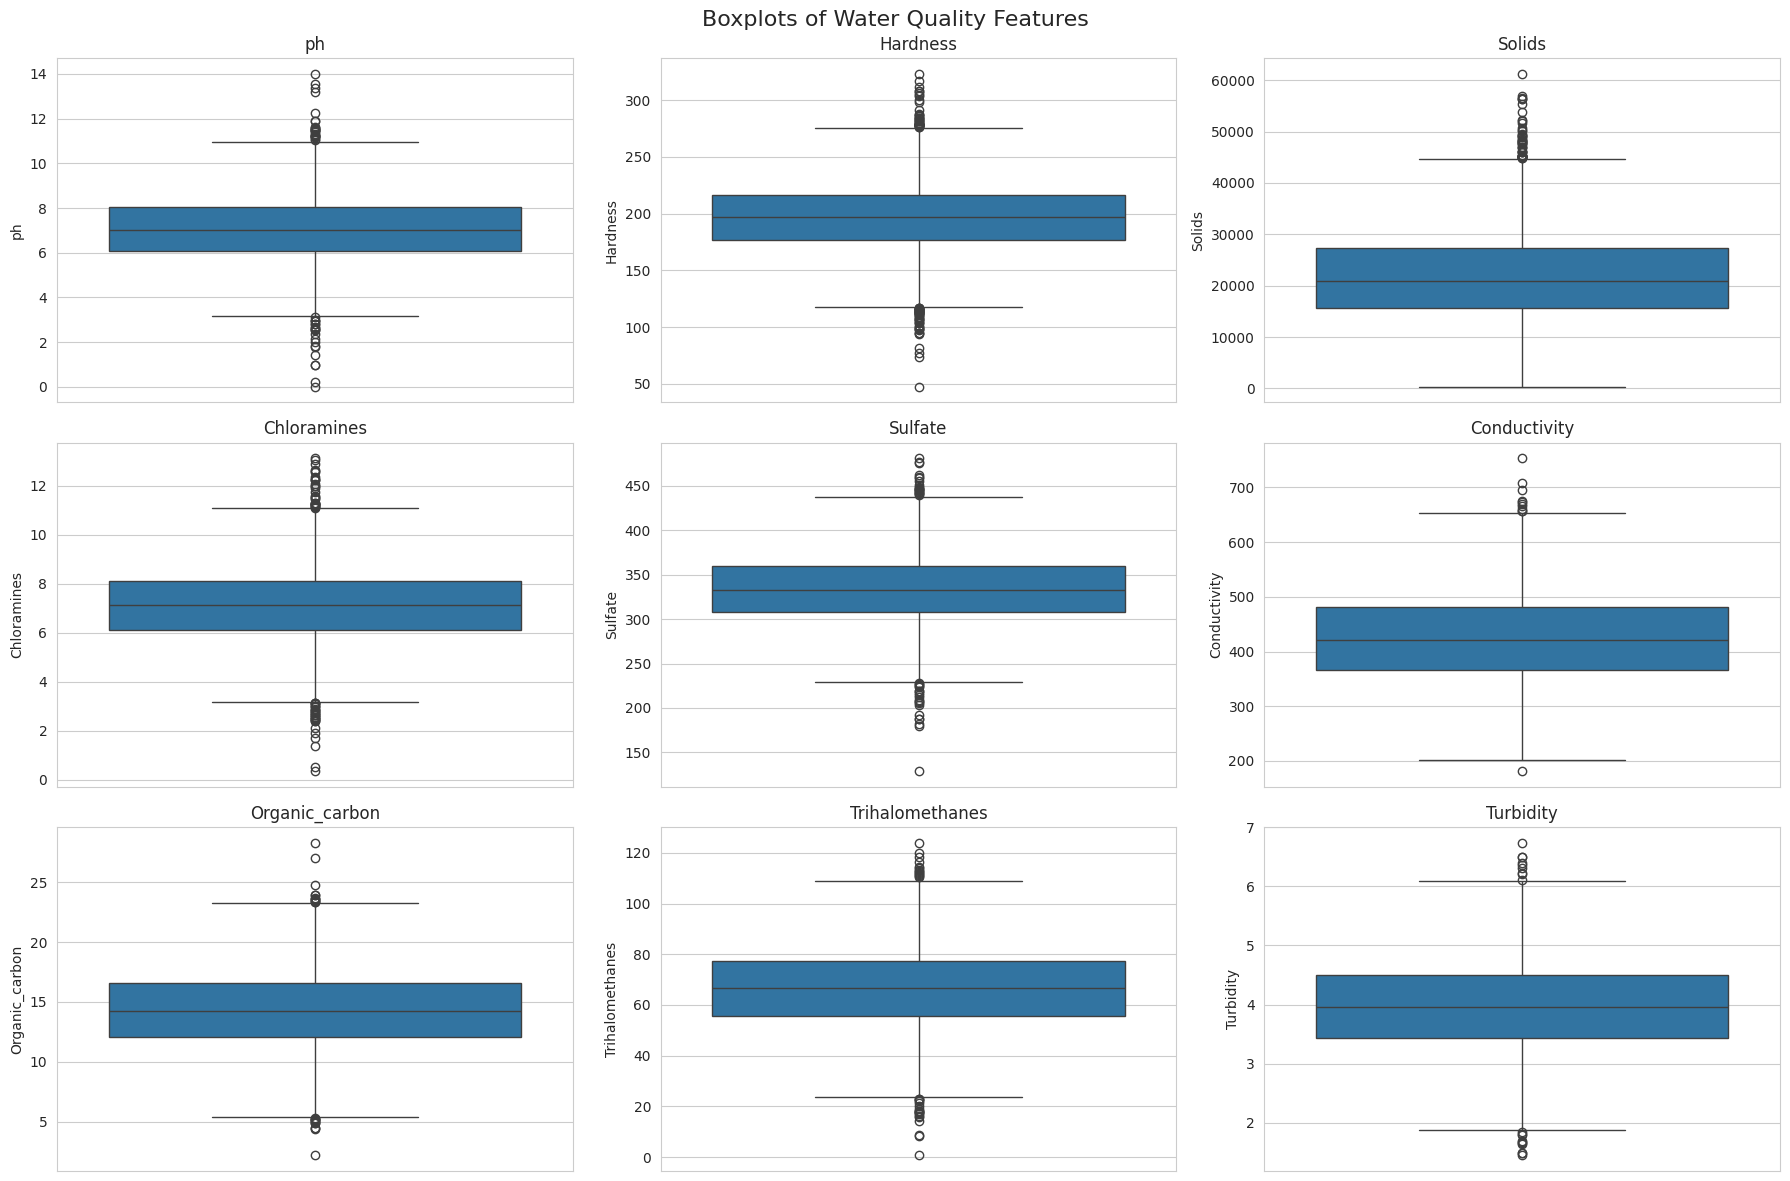

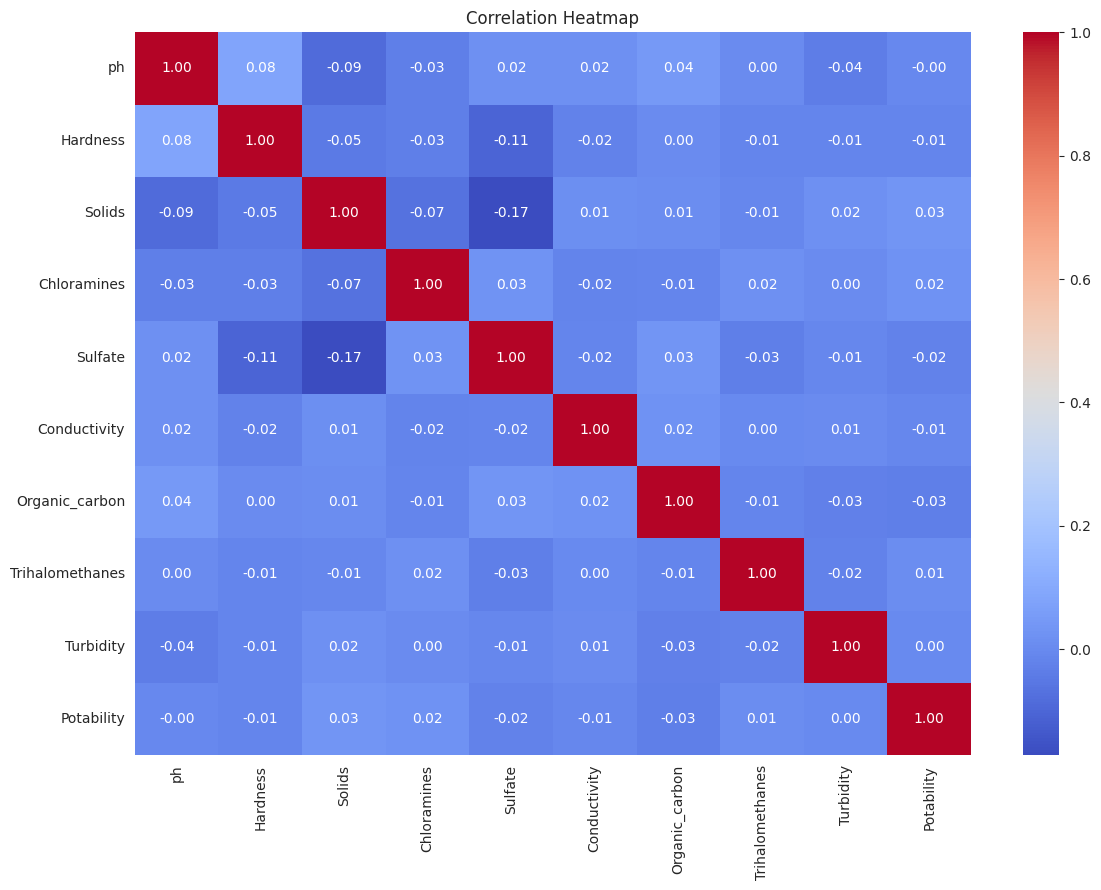

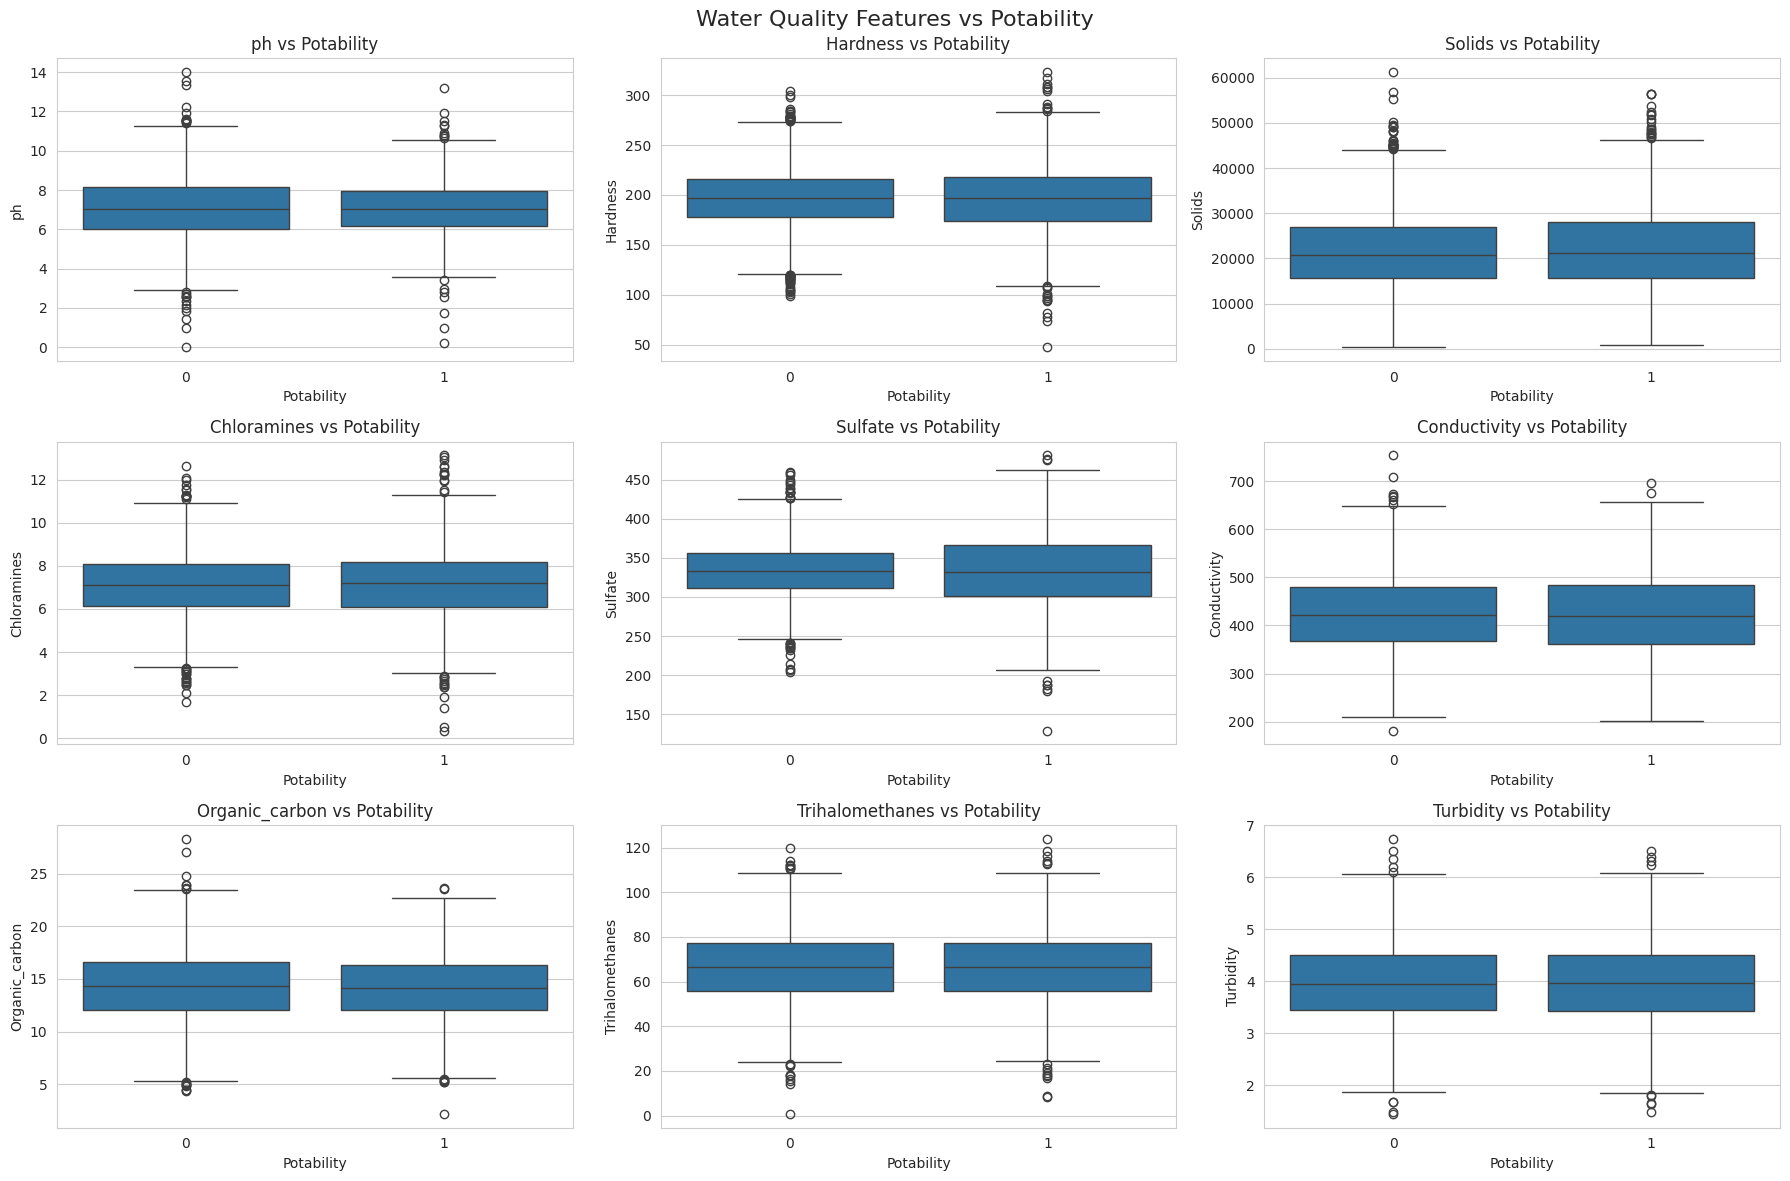


EDA COMPLETED SUCCESSFULLY!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('/content/water_potability.csv')

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFORMATION")
df.info()

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# Missing values
print("\nMISSING VALUES")
print(df.isnull().sum())

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

# Duplicates
print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

# Target variable
print("\nPOTABILITY DISTRIBUTION")
print(df['Potability'].value_counts())

print("\nPOTABILITY PERCENTAGE")
print(df['Potability'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 5))
sns.countplot(x='Potability', data=df)
plt.title("Potable vs Non-Potable Water")
plt.xlabel("Potability (0 = Not Potable, 1 = Potable)")
plt.ylabel("Number of Samples")
plt.show()

features = [
    'ph',
    'Hardness',
    'Solids',
    'Chloramines',
    'Sulfate',
    'Conductivity',
    'Organic_carbon',
    'Trihalomethanes',
    'Turbidity'
]

# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.histplot(df[feature], bins=30, kde=True, ax=axes[row, col])
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Frequency")

plt.suptitle("Distribution of Water Quality Features", fontsize=16)
plt.tight_layout()
plt.show()

# Outlier detection
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.boxplot(y=df[feature], ax=axes[row, col])
    axes[row, col].set_title(feature)
    axes[row, col].set_ylabel(feature)

plt.suptitle("Boxplots of Water Quality Features", fontsize=16)
plt.tight_layout()
plt.show()

# Correlation analysis
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Features vs target
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, feature in enumerate(features):
    row, col = divmod(i, 3)
    sns.boxplot(x='Potability', y=feature, data=df, ax=axes[row, col])
    axes[row, col].set_title(f"{feature} vs Potability")
    axes[row, col].set_xlabel("Potability")

plt.suptitle("Water Quality Features vs Potability", fontsize=16)
plt.tight_layout()
plt.show()

print("\nEDA COMPLETED SUCCESSFULLY!")